In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/online_retail_clean.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
print(df.shape)
df.info()

(1028001, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1028001 entries, 0 to 1028000
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1028001 non-null  str    
 1   StockCode    1028001 non-null  str    
 2   Description  1028001 non-null  str    
 3   Quantity     1028001 non-null  int64  
 4   InvoiceDate  1028001 non-null  str    
 5   Price        1028001 non-null  float64
 6   Customer ID  797885 non-null   float64
 7   Country      1028001 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 62.7 MB


In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1028001 entries, 0 to 1028000
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1028001 non-null  str           
 1   StockCode    1028001 non-null  str           
 2   Description  1028001 non-null  str           
 3   Quantity     1028001 non-null  int64         
 4   InvoiceDate  1028001 non-null  datetime64[us]
 5   Price        1028001 non-null  float64       
 6   Customer ID  797885 non-null   float64       
 7   Country      1028001 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 62.7 MB


## Dataset Overview

The cleaned dataset contains **1,028,001 rows** and **8 columns**

The dataset includes transaction details such as invoice number, product information, quantity, invoice date, unit price, customer ID, and country.

The 'InvocieDate' column was converted from string to datetime format to support time-based analysis during the EDA process.

In [4]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.028001e+06,1028001,1.028001e+06,797885.000000
mean,1.050364e+01,2011-01-04 00:05:26.537542,4.636578e+00,15313.062777
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-05 14:11:00,1.250000e+00,13964.000000
50%,3.000000e+00,2010-12-09 14:09:00,2.100000e+00,15228.000000
75%,1.000000e+01,2011-07-27 15:16:00,4.150000e+00,16788.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.694978e+02,NaN,1.226965e+02,1696.466663


In [5]:
df.describe(include="str")

,Invoice,StockCode,Description,Country
count,1028001,1028001,1028001,1028001
unique,48593,4936,5485,43
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,5651,5740,943286


In [6]:
df.nunique()

Invoice        48593
StockCode       4936
Description     5485
Quantity         740
InvoiceDate    44518
Price           2807
Customer ID     5942
Country           43
dtype: int64

In [7]:
df.isnull().sum()

Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    230116
Country             0
dtype: int64

## Summary Statistics

The dataset contains both numerical and categorical variables representing retail transactions.

The numerical variables include Quantity and Price, while the categorical variables incldue Invoice, StockCode, Description, Customer ID, and Country.

Summary statistics provide and initial understanding of the data distribution before visual exploration. 

## Summary Statistics

The cleand dataset contains **1,028,001 transactions**, **5,942 unique customers**, and **43 countries**.

Most transactions originated fromn the **United Kingdom**, indicating that the dataset is heavily concentrated in one market.

The Quantity and Price variables contain extreme values, suggesting the presence of wholesale purchases, returns, or data adjuistments.

Approximately **230,000 records** have missing Customer IDs, which should be considered when performing customer-level analyses such as RFM segmentation.

In [8]:
negative_qty = df[df["Quantity"] <0]

negative_qty.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [9]:
negative_qty.shape

(19103, 8)

In [10]:
negative_price = df[df["Price"] <0]

negative_price.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
175951,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
270801,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
396041,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
789631,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
789632,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [11]:
negative_price.shape

(5, 8)

In [12]:
zero_price = df[df["Price"] == 0]
zero_price.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4595,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
5821,489861,DOT,DOTCOM POSTAGE,1,2009-12-02 14:50:00,0.0,NaN,United Kingdom
6685,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
15870,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231.0,United Kingdom
18490,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
18491,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
31556,491971,85042,ANTIQUE LILY FAIRY LIGHTS,1,2009-12-14 18:37:00,0.0,NaN,United Kingdom
32463,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,0.0,15070.0,United Kingdom
39540,492760,21143,ANTIQUE GLASS HEART DECORATION,12,2009-12-18 14:22:00,0.0,18071.0,United Kingdom
46321,493761,79320,FLAMINGO LIGHTS,24,2010-01-06 14:54:00,0.0,14258.0,United Kingdom


In [13]:
zero_price.shape

(979, 8)

In [14]:
negative_qty[["Invoice","Description", "Quantity", "Price"]].head(20)

,Invoice,Description,Quantity,Price
178,C489449,PAPER BUNTING WHITE LACE,-12,2.95
179,C489449,CREAM FELT EASTER EGG BASKET,-6,1.65
180,C489449,POTTING SHED SOW 'N' GROW SET,-4,4.25
181,C489449,POTTING SHED TWINE,-6,2.10
182,C489449,PAPER CHAIN KIT RETRO SPOT,-12,2.95
183,C489449,SAVE THE PLANET MUG,-12,1.25
184,C489449,ANTIQUE SILVER TEA GLASS ETCHED,-12,1.25
185,C489449,HANGING HEART ZINC T-LIGHT HOLDER,-24,0.85
186,C489449,PAPER BUNTING RETRO SPOTS,-12,2.95
196,C489459,PURPLE SWEETHEART BRACELET,-3,4.25


## Investigation of Negative and Zero Values

Before performing visual analysis, negative and zero values were investigated to determine whether they represented data quality issues or valid business transactions.

Key findings:

- Transactions with **negative quantities** were associated with invoice numbers beginning with **C**, indicating product returns or cancellations.
- Transactions with **negative prices** were limited to five records labeled **Adjust bad debt**, representing accounting adjustments rather than retail sales.
- Transactions with **zero prices** likely represent promotional items, manual entries, or other special business cases.

These findings suggest that the negative and zero values are meaningful business events rather than simple simple data errors.

In [15]:
sales_df = df[
    (df["Quantity"] > 0) & 
    (df["Price"] >0)
].copy()

sales_df.shape

(1007914, 8)

In [16]:
print(f"Origianl dataset : {len(df):,}")
print(f"Sales dataset : {len(sales_df):,}")
print(f"Removed records :{len(df)-len(sales_df):,} ")

Origianl dataset : 1,028,001
Sales dataset : 1,007,914
Removed records :20,087 


In [17]:
print("Negative Quantity :", (sales_df["Quantity"]<0).sum())
print("Negative Price :", (sales_df["Price"]<0).sum())
print("Zero Price :", (sales_df["Price"]==0).sum())

Negative Quantity : 0
Negative Price : 0
Zero Price : 0


In [18]:
sales_df["Sales"] = sales_df["Quantity"] * sales_df["Price"]

sales_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## Sales Dataset Preparation

To focus on actual pruchaing behavior, a separate sales dataset was created by excluding:

- Returned transactions (Quantity ≤ 0)
- Accounting adjustment records (Price <0)
- Zero-priced transactions (Price = 0)

The original dataset was preserved, while all subsequent exploratory ananlyses were conducted using the filtered sales dataset ('Sales_df').

A new variable, **Sales**, was created by multiplying **Quantity * Price** to represent the total transaction value.


In [19]:
# 1-1 Create Sales Columns

sales_df["Sales"] = sales_df["Quantity"] * sales_df["Price"]

In [20]:
#1-2 Sunnary Statistics

sales_df[["Quantity", "Price", "Sales"]].describe()

,Quantity,Price,Sales
count,1.007914e+06,1.007914e+06,1.007914e+06
mean,1.111717e+01,4.074618e+00,2.031585e+01
std,1.284700e+02,5.043177e+01,2.057160e+02
min,1.000000e+00,1.000000e-03,1.000000e-03
25%,1.000000e+00,1.250000e+00,4.130000e+00
50%,4.000000e+00,2.100000e+00,1.008000e+01
75%,1.200000e+01,4.130000e+00,1.770000e+01
max,8.099500e+04,2.511109e+04,1.684696e+05


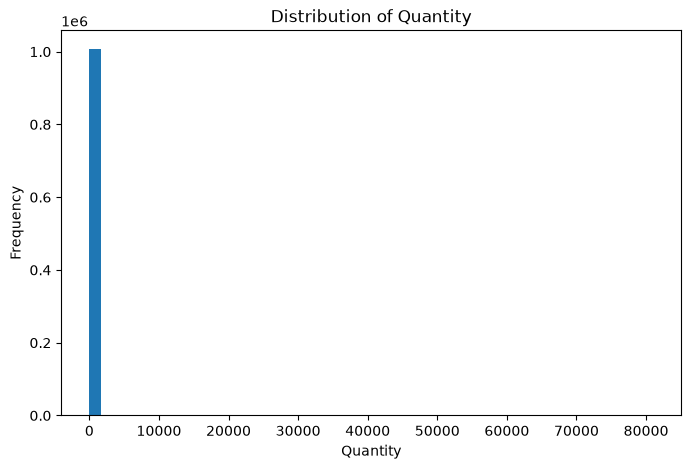

In [21]:
#1-3-1 Quantity Histogram (50개 구간)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(sales_df["Quantity"], bins=50)

plt.title("Distribution of Quantity")

plt.xlabel("Quantity")

plt.ylabel("Frequency")

plt.show()

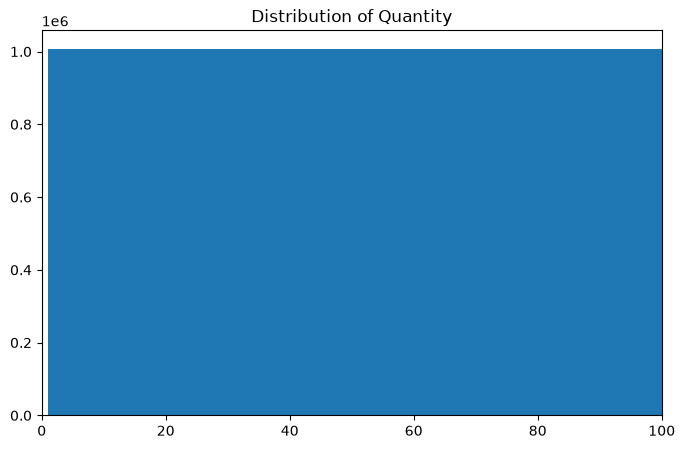

In [22]:
# 1-3-2 Quantity Histogram (X축 범위를 100까지 제한)

plt.figure(figsize=(8,5))

plt.hist(sales_df["Quantity"], bins=50)

plt.xlim(0,100)

plt.title("Distribution of Quantity")

plt.show()

## Distribution of Transaction Sales

Transaction values are highly concentrated at lower sales amounts.

Only a small proportion of transactions generate exceptionally high revenue.

## Business Insight

The majority of transactions are low-value purchases, while a relatively small number of large transactions account for a significant share of revenue. This pattern is common in retail and hightlights the importance of identifying high-value customers. 

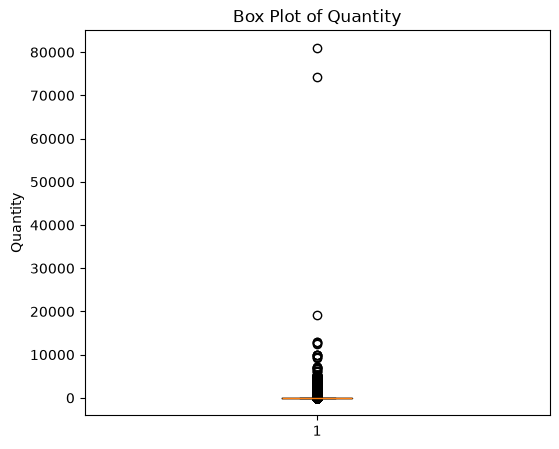

In [23]:
# 2-1 Quantity Box Plot

plt.figure(figsize=(6,5))
plt.boxplot(sales_df["Quantity"])
plt.title("Box Plot of Quantity")
plt.ylabel("Quantity")
plt.show()

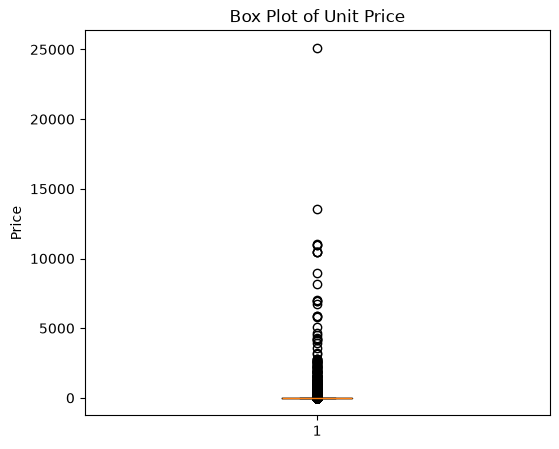

In [24]:
#2-2 Price Box Plot

plt.figure(figsize=(6,5))

plt.boxplot(sales_df["Price"])

plt.title("Box Plot of Unit Price")

plt.ylabel("Price")

plt.show()

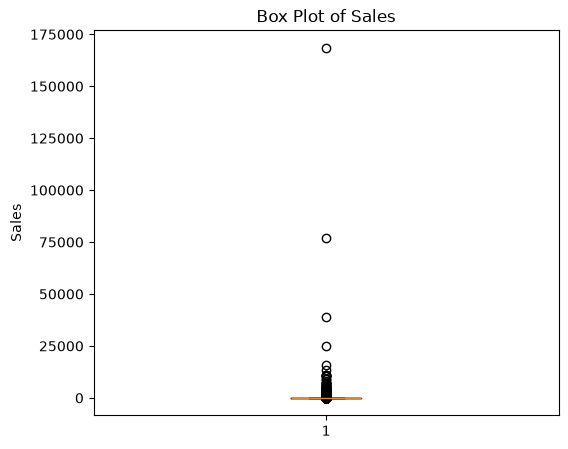

In [25]:
#2-3 Sales Box Plot

plt.figure(figsize=(6,5))

plt.boxplot(sales_df["Sales"])

plt.title("Box Plot of Sales")

plt.ylabel("Sales")

plt.show()

### Box Plot Analysis 

Box plots were used to examine the distribution of Quantity, Price, and Sales while identifying protential outliers.

All three variables exhibit strong right-skewed distributions with numerous observations beyond the upper whisker. These extreme values are consistent with the histogram analysis and likely represent meaningful business events such as bulk purchases, premium-priced products, or high-value customer transactions rather than data errors. 

In [26]:
# 2-4 Outlier Investigation: Sales

sales_df.nlargest(10, "Sales")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
1026519,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60
554116,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60
713089,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,38970.00
236866,512771,M,Manual,1,2010-06-17 16:53:00,25111.09,NaN,United Kingdom,25111.09
424077,530715,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,2010-11-04 11:36:00,1.69,15838.0,United Kingdom,15818.40
507980,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,13541.33
789630,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,11062.06
132260,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918.0,United Kingdom,10953.50
132262,502265,M,Manual,1,2010-03-23 15:28:00,10953.50,NaN,United Kingdom,10953.50
335624,522796,M,Manual,1,2010-09-16 15:12:00,10468.80,NaN,United Kingdom,10468.80


In [27]:
# 2-4 Outlier Investigation: Quantity

sales_df.nlargest(10, "Quantity")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
1026519,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.6
554116,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6
89033,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.10,13902.0,Denmark,1915.2
124582,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark,1296.0
124584,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark,1296.0
124585,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17 13:09:00,0.10,13902.0,Denmark,1274.4
124583,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17 13:09:00,0.10,13902.0,Denmark,1248.0
132274,502269,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom,2500.0
132275,502269,21982,PACK OF 12 SUKI TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom,2500.0
132276,502269,21980,PACK OF 12 RED SPOTTY TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom,2500.0


In [28]:
# 2-4 Outlier Investigation: Price
sales_df.nlargest(10, "Price") 

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
236866,512771,M,Manual,1,2010-06-17 16:53:00,25111.09,NaN,United Kingdom,25111.09
507980,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,13541.33
789630,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,11062.06
132260,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918.0,United Kingdom,10953.50
132262,502265,M,Manual,1,2010-03-23 15:28:00,10953.50,NaN,United Kingdom,10953.50
335624,522796,M,Manual,1,2010-09-16 15:12:00,10468.80,NaN,United Kingdom,10468.80
351868,524159,M,Manual,1,2010-09-27 16:12:00,10468.80,14063.0,United Kingdom,10468.80
365860,525399,M,Manual,1,2010-10-05 11:49:00,10468.80,NaN,United Kingdom,10468.80
73095,496115,M,Manual,1,2010-01-29 11:04:00,8985.60,17949.0,United Kingdom,8985.60
664336,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,8142.75


### Outlier Investigation

The largest Quantity transactions were associated with bulk purchases, suggesting legitimate wholesales or business orders.

The highest Price observations primarily consisted of manual adjustments, administrative charges, and accounting-related records such as "Manual", "AMAZON FEE", and "Adjust bad debt".

The highest Sales transactions were mainly driven by extremely large purchase quantities rather than usually expensive products.

These findings indicate that not all outliers should be treated as data errors. Instead, they represent different business scenarios that should be analyzed separately.

In [29]:
# 3-1. Daily Sales Trend 
# 1) Create Date column

sales_df["Date"] = sales_df["InvoiceDate"].dt.date

In [30]:
# 2) Calculte Daily Sales

daily_sales = (
    sales_df
    .groupby("Date")["Sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,Date,Sales
0,2009-12-01,54351.23
1,2009-12-02,63172.58
2,2009-12-03,73972.45
3,2009-12-04,40582.32
4,2009-12-05,9803.05


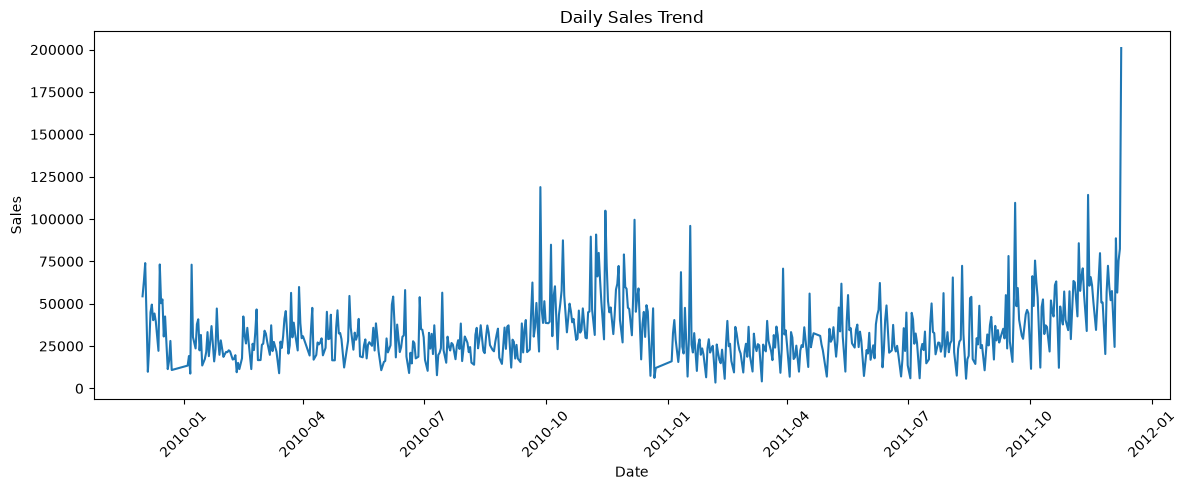

In [31]:
# 3) Create Line Chart of Daily Sales
plt.figure(figsize=(12,5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"]
)

plt.title ("Daily Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Daily Sales Trend

Daily sales were aggreated to examine overall revenue trends over time.

The line chart provides and overview of fluctuations in daily sales and helps identify periods of unusually high or low sales activity. 

Daily sales fluctuate substantially throughtout the observation period.

Despite the high day-to-day variability, the overall trend suggests increasing sales toward the end of 2011.

A pronounced sales spike is observed near the end of the dataset, which is consistent with the bulk purchase transactions identified during the outlier investigation. 

The daily trend also indicates a possbile seasonal increase in sales during the final months of the year.

In [32]:
# 3-2 Montly Sales Trend
# 1) Create Month Column

sales_df["Month"]= sales_df["InvoiceDate"].dt.to_period("M")

In [33]:
# 2) Aggregate Monthly Sales

monthly_sales = (
    sales_df
    .groupby("Month")["Sales"]
    .sum()
    .reset_index()
)

In [34]:
#3) Convert formatting 

monthly_sales["Month"] = monthly_sales["Month"].astype(str)

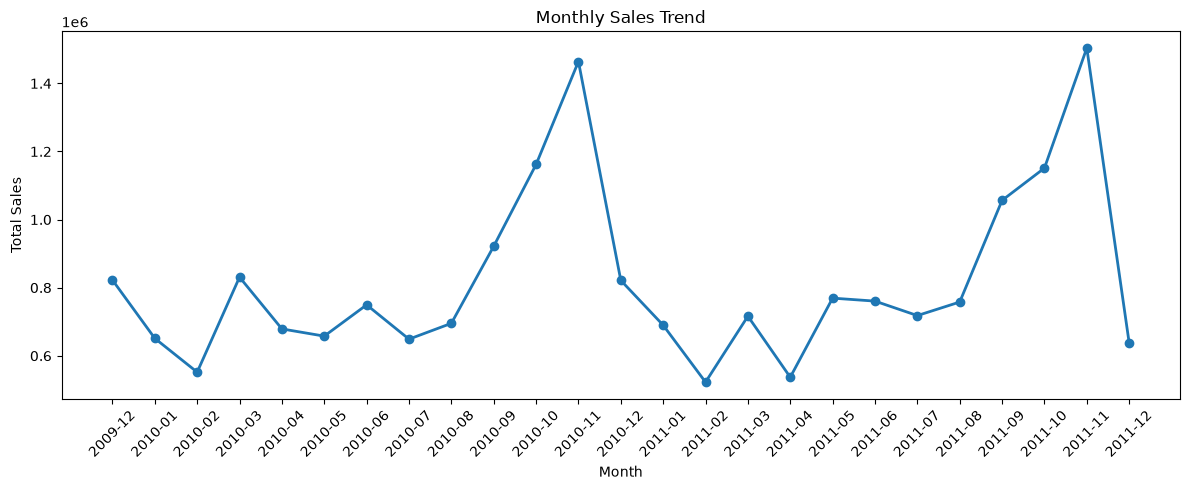

In [35]:
# 4) Montly Sales Trend

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Monthly Sales Trend

Monthly sales reveal a consistent seasonal pattern across both years.

Sales begin to increase around September and reach their highest levels in November, suggesting strong year-end demand.

In addition, overall sales in 2011 are generally higher than those in 2010, indicating continued business growth.

It should be noted that December 2011 contains only partitial-month data, and therefore should not be interpreted as a declind in business performance.


In [36]:
# 3-3 Monthly Order Count

monthly_orders = (
    sales_df
    .groupby("Month")["Invoice"]
    .nunique()
    .reset_index(name="Order Count")
    )

monthly_orders["Month"] = monthly_orders["Month"].astype(str)

monthly_orders.head()

,Month,Order Count
0,2009-12,1682
1,2010-01,1105
2,2010-02,1202
3,2010-03,1681
4,2010-04,1462


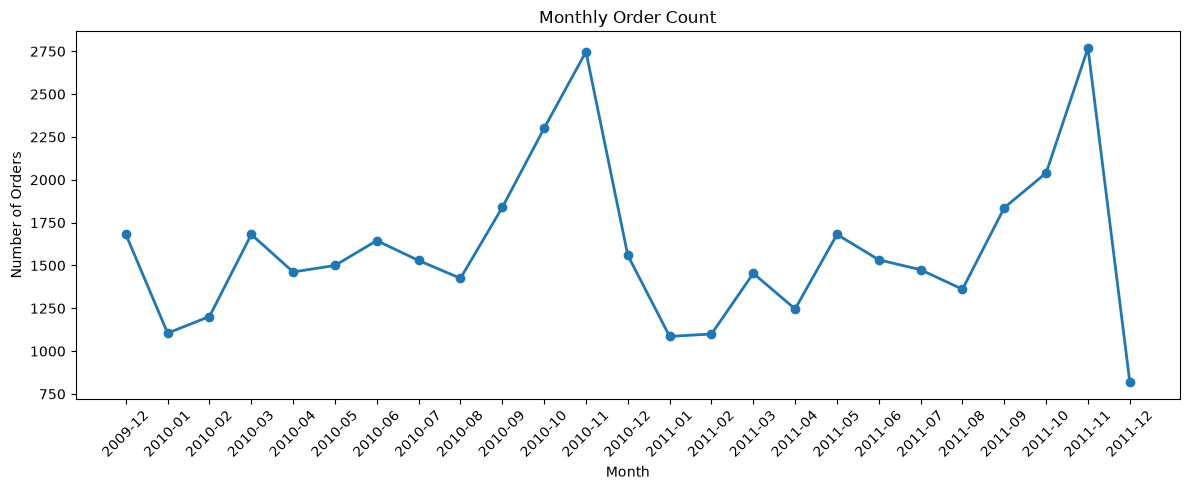

In [37]:
# 3-3 Monthly order chart

plt.figure(figsize=(12,5))

plt.plot(
    monthly_orders["Month"],
    monthly_orders["Order Count"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Order Count")

plt.xlabel("Month")

plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Monthly Order Count

Monthly order counts were caculated to determined whether changes in sales were driven by fluctuations in the number of customer orders.

Tracking order volume helps distinguish between revenue growth resulting from increased purchasing activity and growth driven by higher transaction values.

In [38]:
# 3-4 Monthly Active Customers 

monthly_customers = (
    sales_df
    .dropna(subset=["Customer ID"])
    .groupby("Month")["Customer ID"]
    .nunique()
    .reset_index(name="Active Customer")
)

monthly_customers["Month"] = monthly_customers["Month"].astype(str)

monthly_customers.head()

,Month,Active Customer
0,2009-12,955
1,2010-01,720
2,2010-02,772
3,2010-03,1057
4,2010-04,942


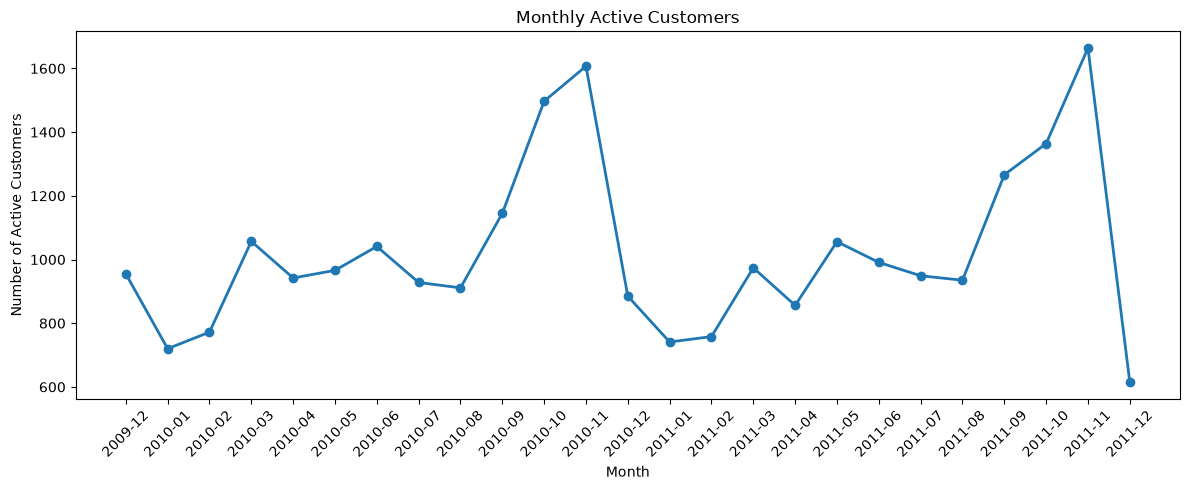

In [39]:
# 3-4 Monthly Active Customer Chart

plt.figure(figsize=(12,5))

plt.plot(
    monthly_customers["Month"],
    monthly_customers["Active Customer"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Active Customers")

plt.xlabel("Month")

plt.ylabel("Number of Active Customers")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Monthly Active Customers

Monthly active customers were measured using unique customer IDs.

This analysis helps determine whether revenue growth is associated with acquiring more customers or changes in customer purchasing behavior.

### Monthly Business Performance

Monthly Sales, Monthly Order Count, and Monthly Active Customers exibit highly consistent trends throughout the observation period.

All three metrics increase substially from September and reach their highest levels in November, suggesting a strong seasonal shopping pattern.

Furthermore, the simultaneous growth of customers, orders, and revenue indicates that business growth is driven by expanding customer activity rather than a small number of exceptional transactions. 

December 2011 contains only partial-month data and should therefore not be interpreted as a decline in business performance.


In [40]:
# 3-5 Average Order Value (AOV)

monthly_aov = monthly_sales.merge(
    monthly_orders,
    on="Month"
)

monthly_aov["AOV"] = (
    monthly_aov["Sales"]/
    monthly_aov["Order Count"]
)

monthly_aov.head()

,Month,Sales,Order Count,AOV
0,2009-12,822483.950,1682,488.991647
1,2010-01,651155.112,1105,589.280644
2,2010-02,551878.296,1202,459.133358
3,2010-03,830915.261,1681,494.298192
4,2010-04,678875.252,1462,464.346958


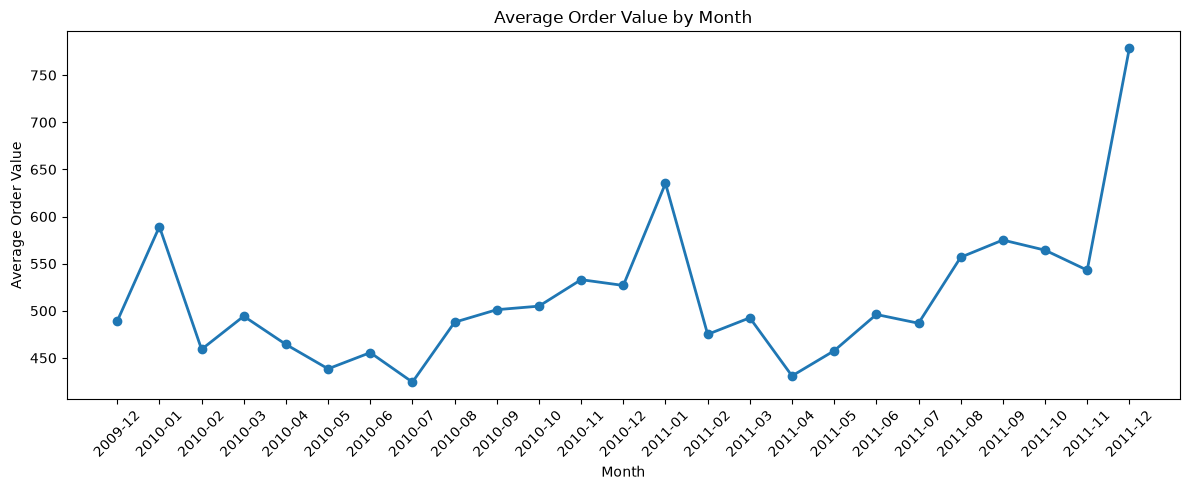

In [41]:
# 3-5 Average Order Value (AOV) Chart

plt.figure(figsize=(12,5))

plt.plot(
    monthly_aov["Month"],
    monthly_aov["AOV"],
    marker = "o",
    linewidth=2
)

plt.title("Average Order Value by Month")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Monthly Average Order Value (AOV)

Average Order Value remained relatively stable throughout most of the analysis period, suggesting that customer spending per order did not change dramatically.

Compared with Sales, Order Count, and Active Customers, the results indicate that revenue growth was primalily driven by increased customer activity rather than substantially higher spending per transaction.

The unusually high AOV observed in December 2011 should be interpreted cautiously because the dataset contains only partial-month data. 

### Business Insight

Monthly business performance demonstrate heathly business growth throught the observation period.

Revenue growth was primarily supported by increases in both order volume and active customers rather than dramatic changes in average order value.

Additionally, the consistent sales peaks observed between September and November suggest a strong seasonal demand pattern, highlighting the importance of inventory planning and marketing campaigns aheds of the year-end shopping season.

In [42]:
# 4-1 Sales by Country

country_sales = (
    sales_df
    .groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending = False)
    .reset_index()
)

country_sales.head(10)

,Country,Sales
0,United Kingdom,1.741057e+07
1,EIRE,6.587673e+05
2,Netherlands,5.540381e+05
3,Germany,4.250197e+05
4,France,3.504561e+05
5,Australia,1.692835e+05
6,Spain,1.083325e+05
7,Switzerland,1.006856e+05
8,Sweden,9.186982e+04
9,Denmark,6.858069e+04


In [43]:
# 4-2 Top 10 Countries 
top10_country_sales = country_sales.head(10)

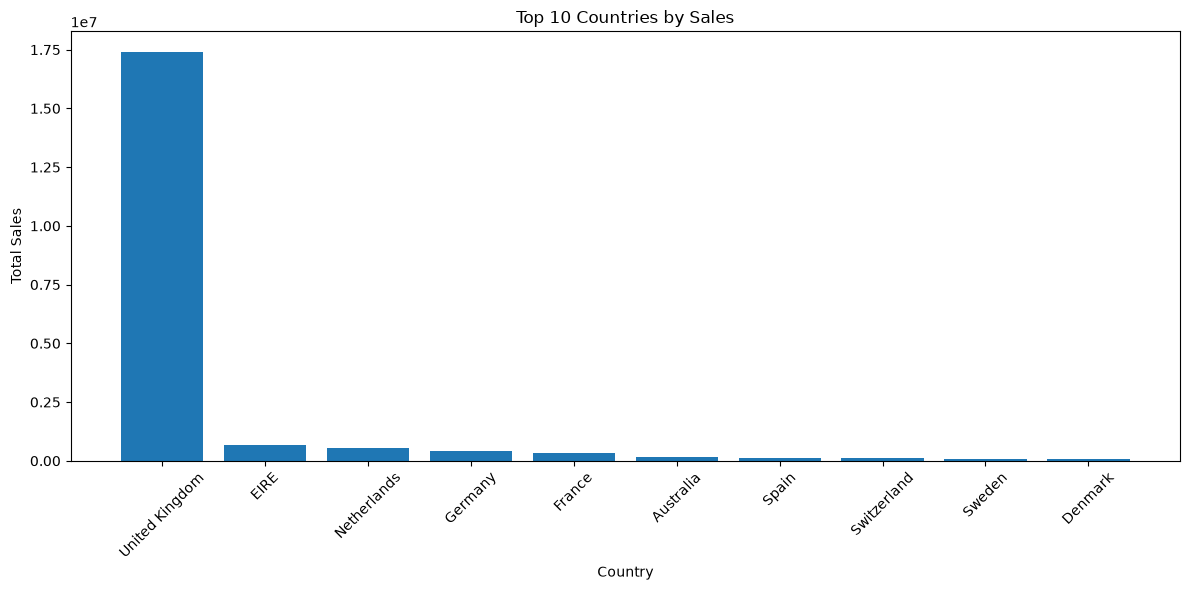

In [44]:
# 4-3 Bar Chart

plt.figure(figsize=(12,6))

plt.bar(
    top10_country_sales["Country"],
    top10_country_sales["Sales"]
)

plt.title("Top 10 Countries by Sales")

plt.xlabel("Country")

plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

##3 Sales by Country

The United Kingdom generates the overwhelming majority of tatal sales, significantly outperforming every other country in the dataseet.

Although several international markets such as EIRE, the Netherlands, Germany, and France contribute meaningful revenue,the business remains highly concentrated in its domestic market.

This geographic concentration suggests opportunities for international expansion while also highlighting potential business risks associated with dependence on a single country. 

In [45]:
# Sales Value excluding UK

country_sales_no_uk = (
    country_sales[country_sales["Country"]!= "United Kingdom"]
    .head(10)
)

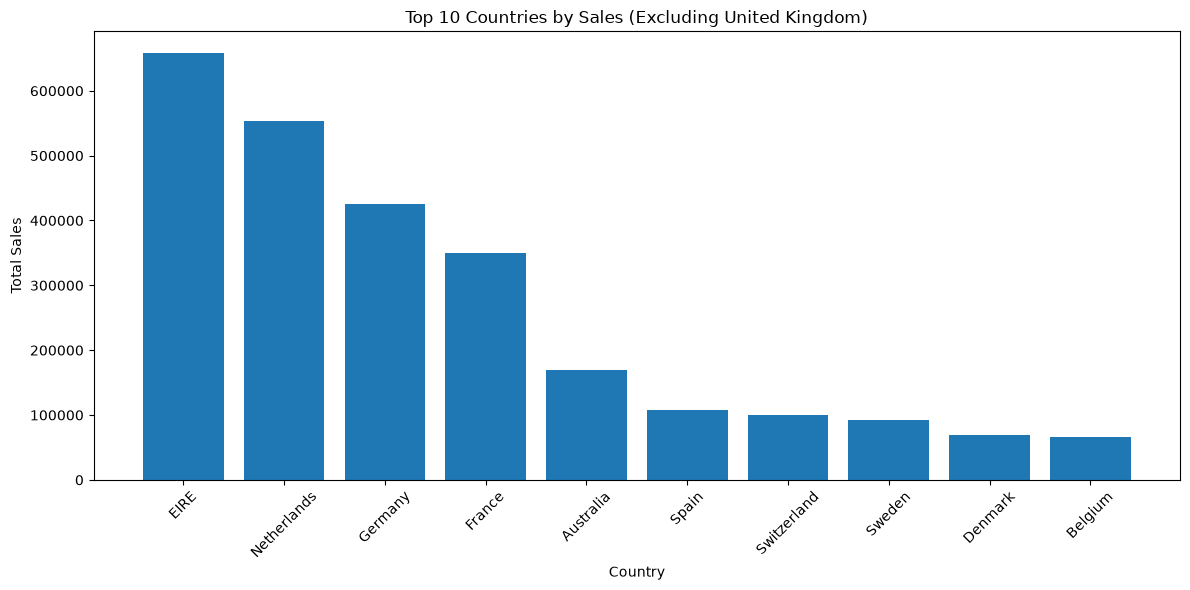

In [46]:
# Chart Excluding UK
plt.figure(figsize=(12,6))

plt.bar(
    country_sales_no_uk["Country"],
    country_sales_no_uk["Sales"]
)

plt.title("Top 10 Countries by Sales (Excluding United Kingdom)")

plt.xlabel("Country")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### International Sales Performance (Excluding United Kingdom)

After excluding the United Kingdom, EIRE emerges as the largest international market, followed by the Netherland, Germany, and France.

International sales are concentrated within a small number of European countries, suggesting that future expansion efforts should prioritize these established markets before entering lower-performing regions.

In [47]:
# 4-2-1 Calculating Unique Customer by Country
country_customers = (
    sales_df
    .groupby("Country")["Customer ID"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="Active Customers")
)

country_customers.head(10)

,Country,Active Customers
0,United Kingdom,5350
1,Germany,107
2,France,95
3,Spain,41
4,Belgium,29
5,Portugal,24
6,Switzerland,22
7,Netherlands,22
8,Sweden,19
9,Italy,17


In [48]:
# 4-2-2 Top 10 Countries With the Most Active Customers

top10_country_customers = country_customers.head(10)


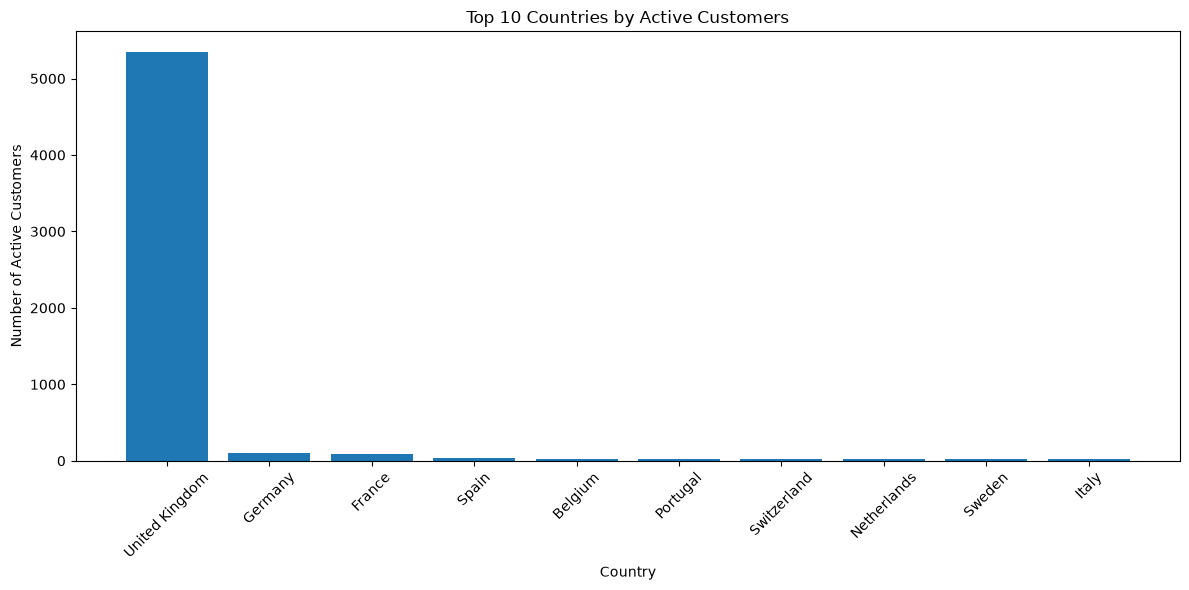

In [49]:
# 4-2-3 Top 10 Countries with the Most Active Customers

plt.figure(figsize=(12,6))

plt.bar(
    top10_country_customers["Country"],
    top10_country_customers["Active Customers"]
)

plt.title("Top 10 Countries by Active Customers")

plt.xlabel("Country")
plt.ylabel("Number of Active Customers")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Active Customers by Country

The United Kingdom has by far the largest active customer base. 

Among international markets, Germany and France have larger customer bases than several countries with higher sales. 

This difference suggests that customer purchasing behavior varies across countries and should be further investigated using Average Order Value (AOV).

In [50]:
# 4-2-4 Top 10 Countries with the Most Active Customers (Excluding UK)

country_customers_no_uk = (
    country_customers[
        country_customers["Country"]!= "United Kingdom"
    ]
    .head(10)
)

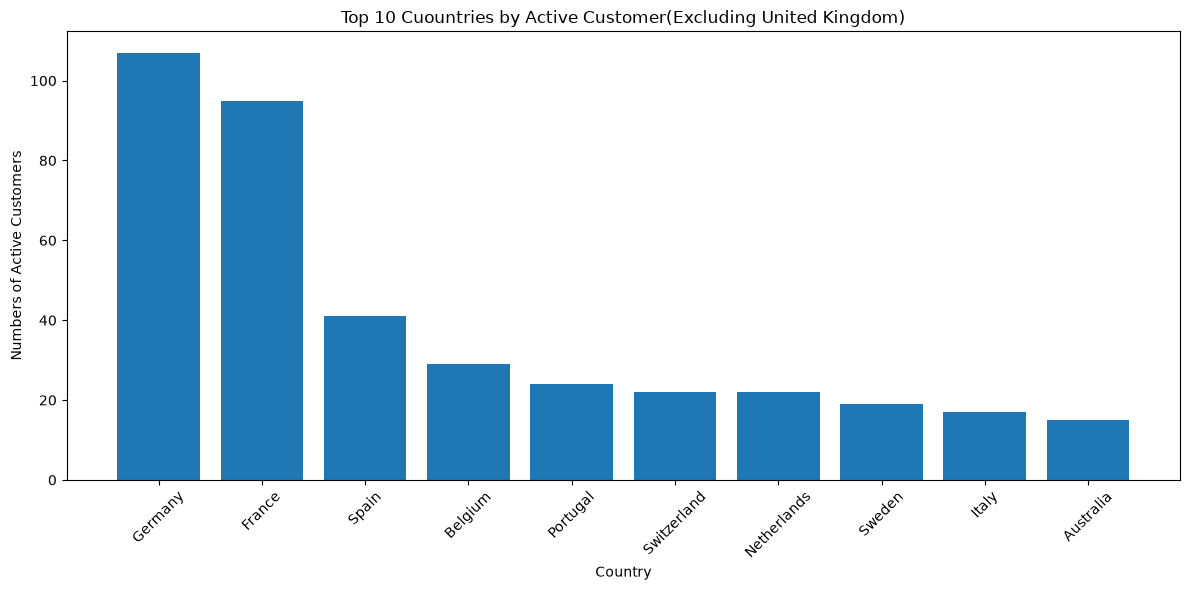

In [51]:
# 4-2-4 Top 10 Countries with the Most Active Customers (Excluding UK)

plt.figure(figsize=(12,6))

plt.bar(
    country_customers_no_uk["Country"],
    country_customers_no_uk["Active Customers"]
)

plt.title("Top 10 Cuountries by Active Customer(Excluding United Kingdom)")

plt.xlabel("Country")
plt.ylabel("Numbers of Active Customers")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### International Active Customers (Excluding United Kingdom)

Germany and France have the largest international customer bases after excluding the United Kingdom.

The ranking of customer counts differs from the ranking of sales, suggesting that purchasing behavior varies across countries.

Markets with many customers may benefit from customer retention strategies, while countries generating high sales with fewer customers may offer opportunities for premium positioning.

## Country Anaysis Summary

The United Kingdom dominates both sales revenue and customer count, confirming its position as the company's primary market.

Among international markets, EIRE generates the highest sales, whereas Germany and France have the largest customer bases.

This difference indicates that customer purchasing behavior varies across countries. Germany and France appear to offer broad customer bases.

Overall, the analysis highlights the importance of adopting country-specific business strategies rather than applying a single global appraoch.

In [52]:
# 4-3-1 Country Average Order Value (AOV) Calculation

country_orders = (
    sales_df
    .groupby("Country")["Invoice"]
    .nunique()
    .reset_index(name="Order Count")
)

country_orders.head()



,Country,Order Count
0,Australia,95
1,Austria,45
2,Bahrain,10
3,Belgium,149
4,Bermuda,1


In [53]:
#4-3-2 Country sales & merge

country_aov = country_sales.merge(
    country_orders,
    on="Country"
)

In [54]:
# 4-3-3 Creating AOV Column

country_aov["AOV"] = (
    country_aov["Sales"]/
    country_aov["Order Count"]
)

country_aov.head()

,Country,Sales,Order Count,AOV
0,United Kingdom,1.741057e+07,36536,476.531905
1,EIRE,6.587673e+05,626,1052.343946
2,Netherlands,5.540381e+05,228,2429.991623
3,Germany,4.250197e+05,789,538.681510
4,France,3.504561e+05,622,563.434228


In [55]:
country_aov.columns

Index(['Country', 'Sales', 'Order Count', 'AOV'], dtype='str')

In [56]:
#4-3-3 Sorting AOV

country_aov = (
    country_aov
    .sort_values(
        by= "AOV",
        ascending=False
    )
)

country_aov.head(10)

,Country,Sales,Order Count,AOV
2,Netherlands,554038.09,228,2429.991623
17,Singapore,25317.06,11,2301.550909
5,Australia,169283.46,95,1781.931158
9,Denmark,68580.69,43,1594.899767
19,Hong Kong,23685.52,15,1579.034667
33,Thailand,3070.54,2,1535.270000
14,Japan,43023.91,33,1303.754848
37,Bermuda,1253.14,1,1253.140000
11,Norway,56322.50,45,1251.611111
31,RSA,4804.32,4,1201.080000


### Country Average Order Value

The Netherlands records the highest Average Order Value among countries with a meaningful number of orders.
EIRE also shows a substantially higher AOV than the United Kingdom, Germany, and France.

Several countries such as Bermuda, Thailand, and RSA appear in the top AOV ranking, but their values are based on very small order counts and should therefore be interpreted cautiously. 

### Interpretation

The country-level analysis confirms that purchasing behavior varies significantly across markets.

Germany and France have relatively large customer bases but lower average order values, while the Netherlands and EIRE generate more revenue per order.

This suggests that international marekts differ not only in customer volume but also in transaction size and pruchasing power.

### Business Insight

The Netherlands represents a particularly attractive international market because it combines high total sales, a meaningful number of orders, and the highest Average Order Value.

EIRE alos demonstrates strong purchasing power per transaction and may respond well to premium product offerings and high_value customer programs.

Germany and France, by contrast, have larger customer bases but lower AOV, suggesting opportunities to increase basket size through cross selling, bundles, and targeted promotions.

Countries with very high AOV but only a few orders should not be prioritized without addtional validation.

In [57]:
#4-3-4 TOP 10 AOV Countries (Countries with Minimum 20 Order counts)

country_aov_filtered = (
    country_aov[
        country_aov["Order Count"] >= 20
    ]
    .sort_values(
        by="AOV",
        ascending=False
    )
)

top10_country_aov_filtered = country_aov_filtered.head(10)

top10_country_aov_filtered

,Country,Sales,Order Count,AOV
2,Netherlands,554038.09,228,2429.991623
5,Australia,169283.46,95,1781.931158
9,Denmark,68580.69,43,1594.899767
14,Japan,43023.91,33,1303.754848
11,Norway,56322.50,45,1251.611111
7,Switzerland,100685.59,93,1082.640753
1,EIRE,658767.31,626,1052.343946
8,Sweden,91869.82,105,874.950667
13,Channel Islands,44623.33,55,811.333273
6,Spain,108332.49,154,703.457727


Countries with fewer than 20 orders were excluded from the comparision to reduce the influence of extremely small samples. 

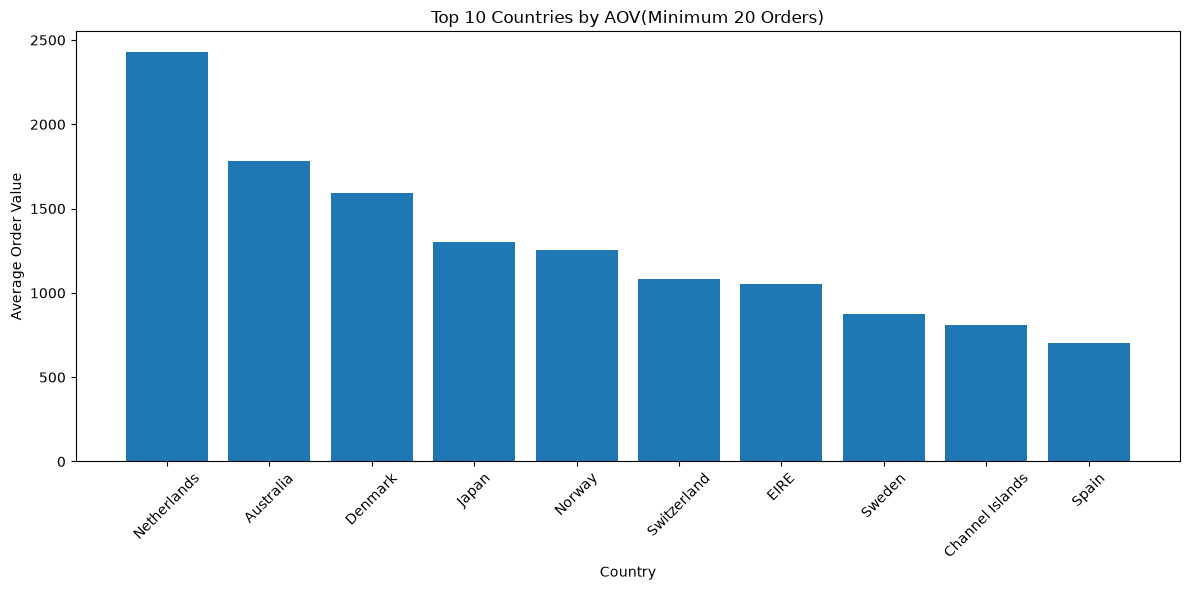

In [58]:
# 4-3-5 TOP AOV Countries (Countries with Minimum 20 Order counts)

plt.figure(figsize=(12,6))

plt.bar(
    top10_country_aov_filtered["Country"],
    top10_country_aov_filtered["AOV"]
)

plt.title("Top 10 Countries by AOV(Minimum 20 Orders)")
plt.xlabel("Country")
plt.ylabel("Average Order Value")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Business Insight

The Netherlands stands out as the strongest high-value international market, combining substial sales with the highest Average Order Value among countries with at least 20 orders.

Australia, Denmark, Japan, and Norway also demonstrate relatively high spending per order and may be suitable for premium product offerings and targeted high-value campaigns.

By contranst, markets with larger customer bases but lower AOV may benefit from cross-selling, product bundles, and promotions designed to increase basket size. 

### Country Average Order Value 

To reduce the influence of extremely samll samples, only countries with at least 20 unique orders were included in the comparision.

The Netherlands records the highest Average Order Value, followed by Australia, Denmark, Japan, and Norway.

These results show that customer spending per transaction differs significantly across international markets. Countries with high AOV may offer opportunities for premium positioning while markets with lower AOV may require strategies focused on increasing basket size. 

In [59]:
# 5-1-1 Top Products by Sales 

product_sales = (
    sales_df
    .groupby("Description")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

product_sales.head(10)

,Description,Sales
0,Manual,339614.86
1,REGENCY CAKESTAND 3 TIER,330590.32
2,DOTCOM POSTAGE,309854.11
3,WHITE HANGING HEART T-LIGHT HOLDER,260990.22
4,"PAPER CRAFT , LITTLE BIRDIE",168469.60
5,PARTY BUNTING,148318.28
6,JUMBO BAG RED RETROSPOT,148073.47
7,ASSORTED COLOUR BIRD ORNAMENT,129324.49
8,POSTAGE,125682.42
9,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29


In [60]:
# 5-1-2 Top 10 Products by sales

top10_products = product_sales.head(10)

top10_products

,Description,Sales
0,Manual,339614.86
1,REGENCY CAKESTAND 3 TIER,330590.32
2,DOTCOM POSTAGE,309854.11
3,WHITE HANGING HEART T-LIGHT HOLDER,260990.22
4,"PAPER CRAFT , LITTLE BIRDIE",168469.60
5,PARTY BUNTING,148318.28
6,JUMBO BAG RED RETROSPOT,148073.47
7,ASSORTED COLOUR BIRD ORNAMENT,129324.49
8,POSTAGE,125682.42
9,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29


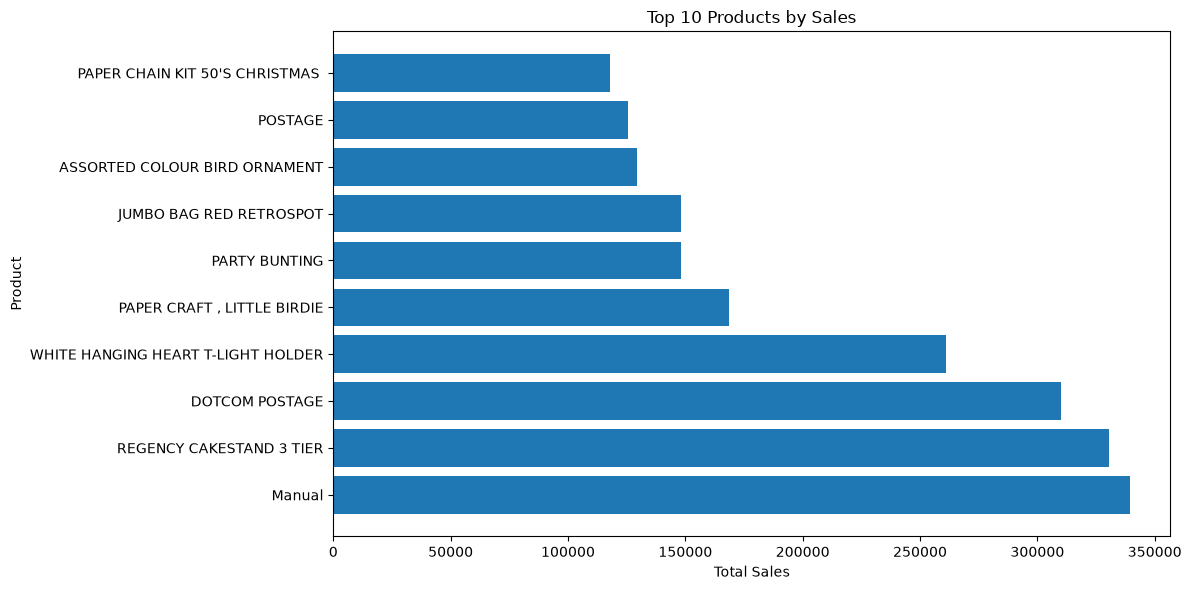

In [61]:
# 5-1-3 Top 10 Products by Sales (chart)

plt.figure(figsize=(12,6))

plt.barh(
    top10_products["Description"],
    top10_products["Sales"]
)

plt.title("Top 10 Products by Sales")

plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.tight_layout()

plt.show()

In [62]:
# 5-1-3 Product Sales exclduing non-product item

non_product_items = [
    "Manual", 
    "DOTCOM POSTAGE",
    "POSTAGE",
    "AMAZONE FEE",
    "Adjust bad debt"
]

product_df = sales_df[
    ~sales_df["Description"].isin(non_product_items)
    ].copy()


In [63]:
product_df[
    product_df["Description"].isin(non_product_items)
].shape

(0, 11)

In [64]:
# 5-1-4 Recalculating sales after excluding non-product items

product_sales_clean = (
    product_df
    .groupby("Description")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top10_products_clean = product_sales_clean.head(10)

top10_products_clean

,Description,Sales
0,REGENCY CAKESTAND 3 TIER,330590.32
1,WHITE HANGING HEART T-LIGHT HOLDER,260990.22
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3,PARTY BUNTING,148318.28
4,JUMBO BAG RED RETROSPOT,148073.47
5,ASSORTED COLOUR BIRD ORNAMENT,129324.49
6,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29
7,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
8,CHILLI LIGHTS,80540.88
9,ROTATING SILVER ANGELS T-LIGHT HLDR,71300.40


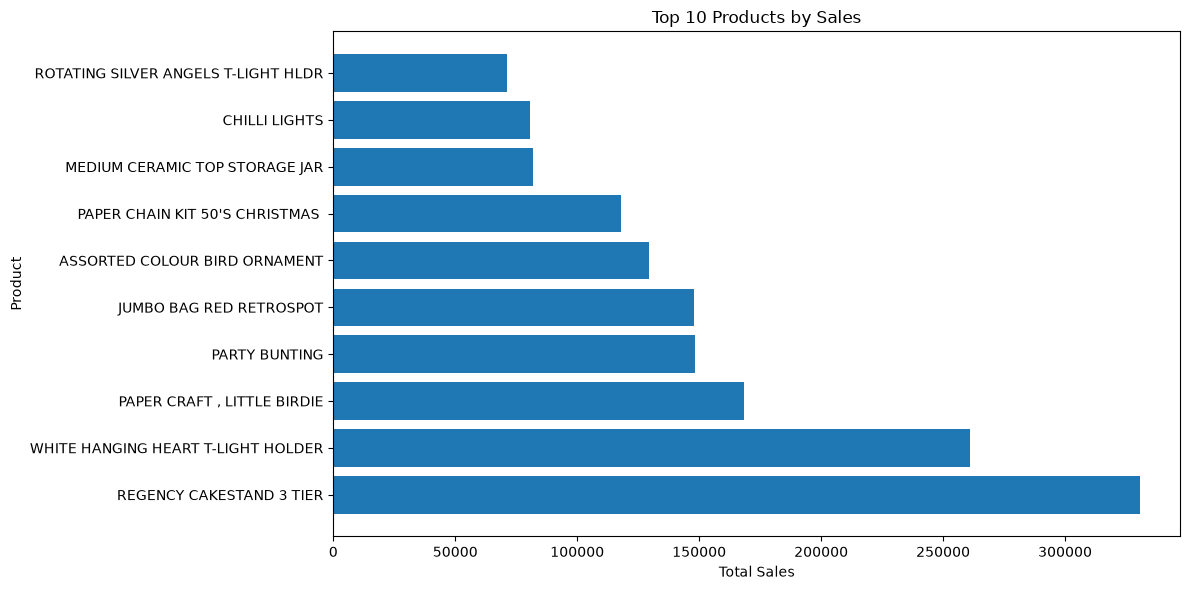

In [65]:
# 5-1-5 Top 10 product by sales (after exclduing non-product)

plt.figure(figsize=(12,6))

plt.barh(
    top10_products_clean["Description"],
    top10_products_clean["Sales"]
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.gca().invert_yaxis

plt.tight_layout()
plt.show()


### Business Insight

The company's highest-revenue products are primarily home decoration and lifestyle items.

These products should recieve priority in inventory management, promotional campaigns, and product availability planning. 

However, products with exceptionally large single orders should be evaluated together with sales quantity to distinguish consistently popular products from one-time bulk purchases.

### Top Products by Sales

After excluding non-product records such as postage and manaual adjustments, products were ranked by total sales revenue.

Home decoration and lifestyle products dominate the ranking, with REGENCY CAKESTAND 3TIER ann WHITE HANGING HEART T-LIGHT HOLDER generating the highest revenue.

Some products may rank highly due to unusually large individual orders, so sales quantity analysis is required to validate consistent demand.

In [66]:
# 5-2 Top products by quantity 

product_quantity = (
    product_df
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

product_quantity.head(10)

,Description,Quantity
0,WORLD WAR 2 GLIDERS ASSTD DESIGNS,106139
1,WHITE HANGING HEART T-LIGHT HOLDER,94658
2,"PAPER CRAFT , LITTLE BIRDIE",80995
3,ASSORTED COLOUR BIRD ORNAMENT,80082
4,MEDIUM CERAMIC TOP STORAGE JAR,78033
5,JUMBO BAG RED RETROSPOT,77699
6,BROCADE RING PURSE,70369
7,PACK OF 60 PINK PAISLEY CAKE CASES,56061
8,60 TEATIME FAIRY CAKE CASES,54028
9,SMALL POPCORN HOLDER,48561


In [67]:
# 5-2-2 Top 10 Products by quantity 

top10_quantity = product_quantity.head(10)

top10_quantity

,Description,Quantity
0,WORLD WAR 2 GLIDERS ASSTD DESIGNS,106139
1,WHITE HANGING HEART T-LIGHT HOLDER,94658
2,"PAPER CRAFT , LITTLE BIRDIE",80995
3,ASSORTED COLOUR BIRD ORNAMENT,80082
4,MEDIUM CERAMIC TOP STORAGE JAR,78033
5,JUMBO BAG RED RETROSPOT,77699
6,BROCADE RING PURSE,70369
7,PACK OF 60 PINK PAISLEY CAKE CASES,56061
8,60 TEATIME FAIRY CAKE CASES,54028
9,SMALL POPCORN HOLDER,48561


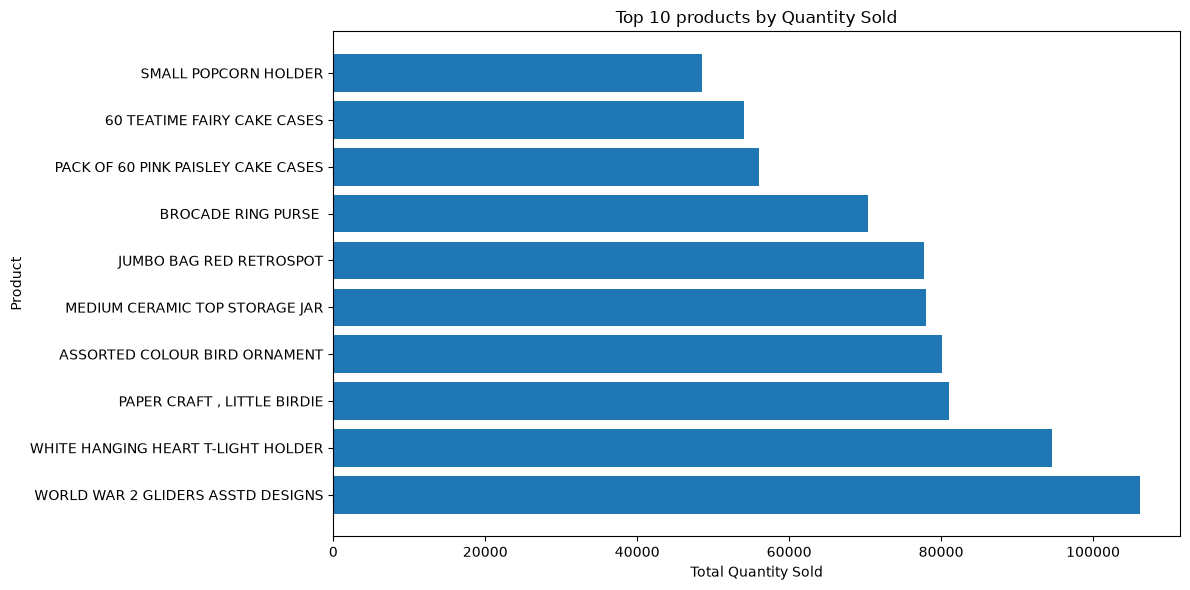

In [68]:
# 5-2-3 Top 10 Product by visualization

plt.figure(figsize=(12,6))

plt.barh(
    top10_quantity["Description"],
    top10_quantity["Quantity"]
)

plt.title("Top 10 products by Quantity Sold")

plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")

plt.gca().invert_yaxis

plt.tight_layout()

plt.show()

### Business Insight

Products such as WHITE HANGING HEART T-LIGHT HOLDER and JUMBO BAG RETROSPOT perform strongly is both revenue and sales volume, making them core products for the business.

Products that rank highly in quantity but not in revenue may represent low-priced, high-volume items that attract customers and encourage repeat purchaes.

Conversely, products with high revenue but relatively lower sales volume may be premium-priced products that contribute significantly to profitability.

### Top Products by Quantity Sold

The products with the highest sales volume differ from those generating the highest revenue

This Indicates taht some products succeed through high sales volume, while others contribute more revenue because of higher prices.

Products that rank highly in both revenue and quantity represent the company's strongest core products.

In [ ]:
# 5-3 Preto Analysis
# 1) Confriming Product Sales Ranking 
product_sales_clean.head()

,Description,Sales
0,REGENCY CAKESTAND 3 TIER,330590.32
1,WHITE HANGING HEART T-LIGHT HOLDER,260990.22
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3,PARTY BUNTING,148318.28
4,JUMBO BAG RED RETROSPOT,148073.47


In [70]:
# 5-3 Paretp Analysis 
# 2) Caculating Cumulative Sales
pareto_df = product_sales_clean.copy()

pareto_df["Cumulative Sales"] = (
    pareto_df["Sales"].cumsum()
)

pareto_df["Cumulative Percentage"] = (
    pareto_df["Cumulative Sales"]
    /pareto_df["Sales"].sum()
    *100
)

pareto_df.head()

,Description,Sales,Cumulative Sales,Cumulative Percentage
0,REGENCY CAKESTAND 3 TIER,330590.32,330590.32,1.678940
1,WHITE HANGING HEART T-LIGHT HOLDER,260990.22,591580.54,3.004408
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60,760050.14,3.860000
3,PARTY BUNTING,148318.28,908368.42,4.613250
4,JUMBO BAG RED RETROSPOT,148073.47,1056441.89,5.365258


In [ ]:
# 5-3 Pareto Analysis 
# 3) How many products are within 80%? 

pareto_80 = pareto_df[
    pareto_df["Cumulative Percentage"] <=80
]

len(pareto_80)

1182

In [73]:
# 5-3 Pareto Analysis
# 4) Ratio to total products
print("Products for 80% Sales :", len(pareto_80))

print("Total Products :", len(pareto_df))

print(
    "Percentage :",
    round(
        len(pareto_80)
        / len(pareto_df)
        *100, 
        2
    ),
    "%"
)

Products for 80% Sales : 1182
Total Products : 5395
Percentage : 21.91 %


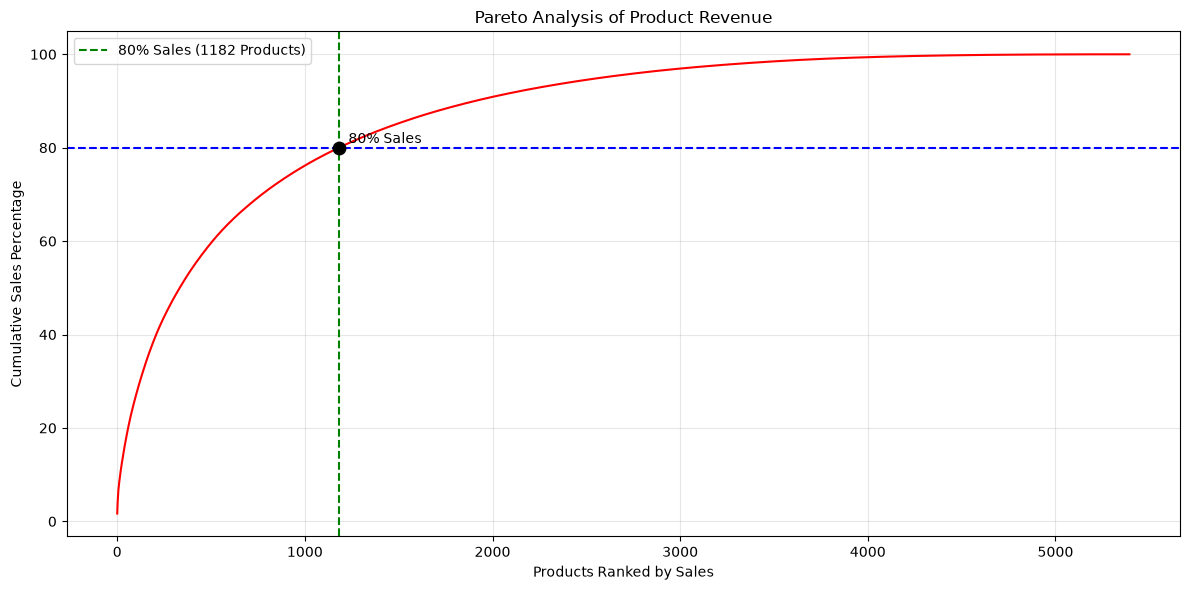

In [81]:
# 5-3 Pareto Analysis
# 5) Pareto Chart

plt.figure(figsize=(12,6))

plt.plot(
    pareto_df["Cumulative Percentage"],
    color="red"
)

plt.axhline(
    y=80,
    color="blue",
    linestyle="--"
)

plt.axvline(
    x=len(pareto_80),
    color="green",
    linestyle="--",
    label=f"80% Sales ({len(pareto_80)} Products)"
)

plt.legend()

plt.scatter(
    len(pareto_80),
    80,
    color="black",
    s=80,
    zorder=5
)

plt.text(
    len(pareto_80)+50,
    81,
    "80% Sales",
    fontsize=10
)

plt.title("Pareto Analysis of Product Revenue")

plt.xlabel("Products Ranked by Sales")

plt.ylabel("Cumulative Sales Percentage")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Observation

Approxomately 1,182 out of 5,395 products generate 80% of the company's total sales.

This means that only 21.9% of all products account for majority of business revenue.

### Interpretation 

The product portfolio exhibits a classic Pareto distribution.

A relatively samll subset of products contributes disproportionately to total revenue, while the majority of products generate comparatively smaller sales.

### Business Insight

The Company should prioritize its highest-performing 22% of products for inventory management, demand forecasting, and promotional activities.

These products represent the core revenue drivers and should recieve greater operational focus.

Lower-performing products should be periodically reviewed to determine whether they require promotional support, portfolio optimization, or discontinuation.

### Pareto Analysis (80/20 Rule)

The cumulative sales analysis shows that approximately 1,182 out of 5,395 products generate 80% of the company's total sales.

This represents 21.9% of the entire product portfolio, indicating that the sales distribution closely follows the Pareto Principle.

The result suggests that a relatively small group of products serves as the company's primary revenue drivers.

In [82]:
# 5-4 Product Price Distribution
# 1) Summary Statistics
sales_df["Price"].describe()

count    1.007914e+06
mean     4.074618e+00
std      5.043177e+01
min      1.000000e-03
25%      1.250000e+00
50%      2.100000e+00
75%      4.130000e+00
max      2.511109e+04
Name: Price, dtype: float64

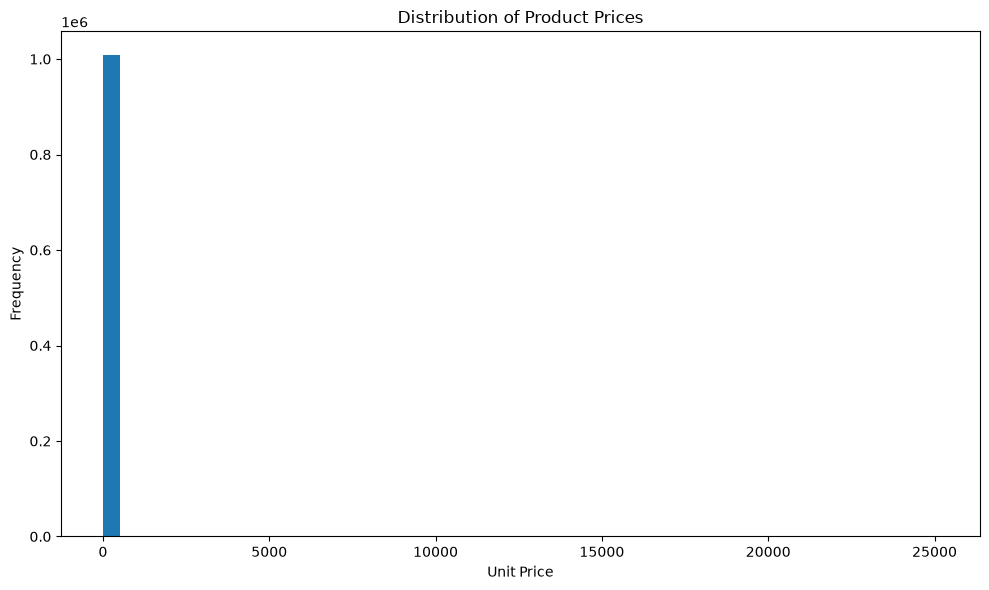

In [ ]:
# 5-4 Product Price Distribution
# 2) Price Distribution 
# 5-4-2 Price Distribution

plt.figure(figsize=(10,6))

plt.hist(
    sales_df["Price"],
    bins=50
)

plt.title("Distribution of Product Prices")

plt.xlabel("Unit Price")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

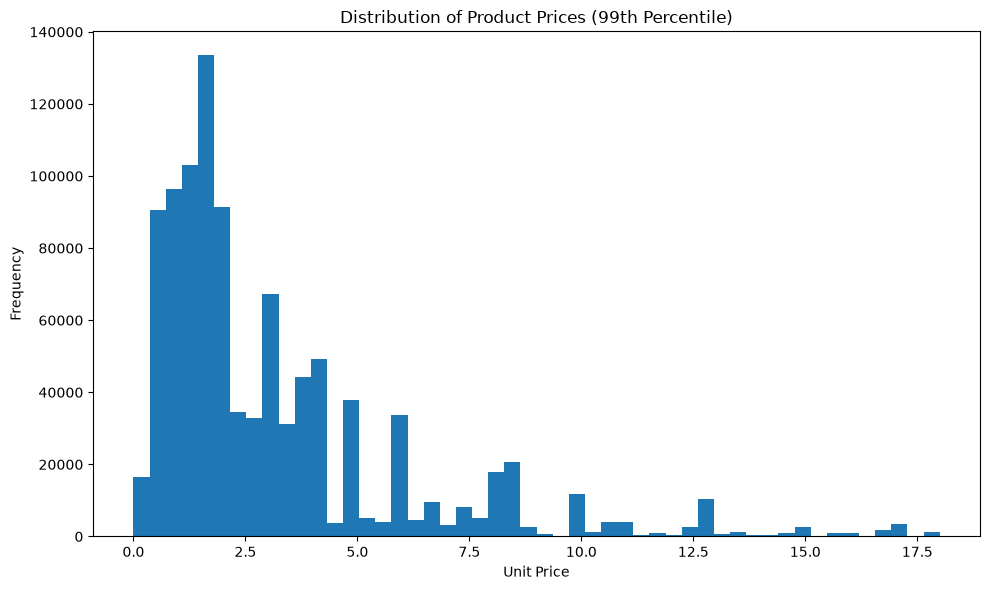

In [85]:
# 5-4 Product Price Distribution
# 2) Price Distribution (Exclduing top 1% of price)
price_limit = sales_df["Price"].quantile(0.99)

plt.figure(figsize=(10,6))

plt.hist(
    sales_df[sales_df["Price"] <= price_limit]["Price"],
    bins=50
)

plt.title("Distribution of Product Prices (99th Percentile)")

plt.xlabel("Unit Price")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Observation

The majority of products are priced between approximately ₤1 and ₤3.

Product frequency decreases as price increases, resulting in a right-skewed distribution with only a small number of higher-priced products.

### Interpretation

The business primarily sells low-priced products while maintaining a relatively small selection of premium-priced products.

This pricing structure suggests a retail business focused on high transaction volume rather than high unit prices.

### Business Insight

The company's revenue model appears to rely on selling a large volume of affordable products.

Low-priced products are likely to encourage frequent purchases, while higher-priced products may contribute disproportionately to profit margins.

Maintaining inventory availabilty for popular low-priced products should therefore be a key operational priority.

### Why 99th percentile applied 

Extreme price outliers were excluded using the 99th percentile to better visualize the underlying distribution of typical product prices.

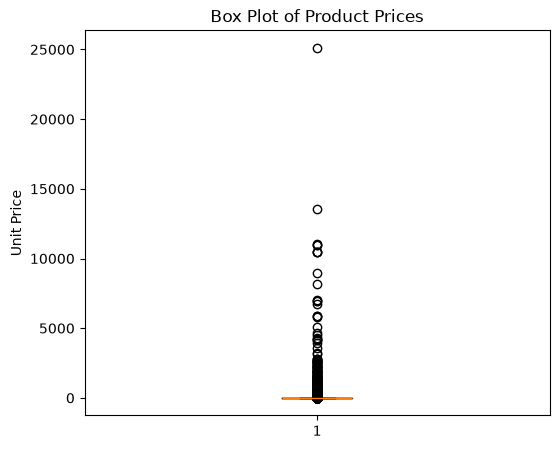

In [87]:
# 5-4 Product Price Box Plot
# 3) Price Box Plot 

plt.figure(figsize=(6,5))

plt.boxplot(sales_df["Price"])

plt.title("Box Plot of Product Prices")

plt.ylabel("Unit Price")

plt.show()


In [88]:
# 5-4 Product Price Box Plot
# 4) Highest Priced Products

sales_df.nlargest(
    10,
    "Price"
)[
    [
        "Description",
        "Price",
        "Quantity",
        "Country"
    ]
]

,Description,Price,Quantity,Country
236866,Manual,25111.09,1,United Kingdom
507980,AMAZON FEE,13541.33,1,United Kingdom
789630,Adjust bad debt,11062.06,1,United Kingdom
132260,Manual,10953.50,1,United Kingdom
132262,Manual,10953.50,1,United Kingdom
335624,Manual,10468.80,1,United Kingdom
351868,Manual,10468.80,1,United Kingdom
365860,Manual,10468.80,1,United Kingdom
73095,Manual,8985.60,1,United Kingdom
664336,POSTAGE,8142.75,1,United Kingdom


### Observation 

Most products are concentrated within a relatively low price range.

The box plot reveals numerous high-priced outliers, but futher investigation shows aht these records are primarily manual adjustments, postage charges, and accounting-related entries rather than actual retail products.

### Interpretation

The apprent high-price outliers do not represent premium retail products.

Instead, they are administrative or accounting records that distort the overall price distribution.

Removing or excluding these records provides a more accurate representation of the company's pricing strategy. 

### Business Insight

The company primarily operates as a low priced retail business.

Extreme price values are largely associated with non-product transactions rather than customer purchases.

Therefore, data cleaning and business-rule validation are essentail before performing pricing pr profitability analyses.